In [1]:
aie_interval_1 = {
    #'32x32': 90,
    #'32x64': 128.71,
    '64x64': 179.91,
    '64x96': 239.29,
    '64x128': 298.67,
    '96x96': 316.09,
    '96x128': 401.07,
    '128x128': 503.47
}

aie_interval_2 = {
    '64x64': 136.18,
    '64x96': 144.0,
    '64x128': 159.82,
    '96x96': 163.2,
    '96x128': 185.42,
    '128x128': 212.08
}

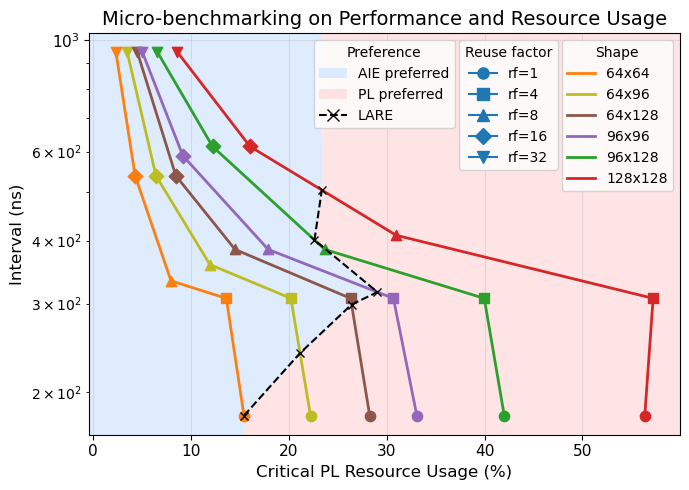

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import numpy as np
import pandas as pd


def read_tradeoff(csv_name):
    csv_path = Path(csv_name)
    if not csv_path.exists():
        csv_path = Path('dense_exp/obbg_plot') / csv_name
    df = pd.read_csv(csv_path).sort_values('Interval(ns)')
    return df['lut'].to_numpy(), df['Interval(ns)'].to_numpy(), df['rf'].to_numpy()


def locate_x_on_line(x, y, target_y):
    log_y = np.log10(y)
    target_log_y = np.log10(target_y)
    for i in range(len(x) - 1):
        y0, y1 = log_y[i], log_y[i + 1]
        if min(y0, y1) <= target_log_y <= max(y0, y1):
            t = (target_log_y - log_y[i]) / (log_y[i + 1] - log_y[i])
            return x[i] + t * (x[i + 1] - x[i])

    if target_log_y < log_y.min():
        i = len(x) - 2
    elif target_log_y > log_y.max():
        i = 0
    else:
        return None

    t = (target_log_y - log_y[i]) / (log_y[i + 1] - log_y[i])
    return x[i] + t * (x[i + 1] - x[i])


line_colors = {
    #'32x32': '#1f77b4',
    #'32x64': '#17becf',
    '64x64': '#ff7f0e',
    '64x96': '#bcbd22',
    '64x128': '#8c564b',
    '96x96': '#9467bd',
    '96x128': '#2ca02c',
    '128x128': '#d62728'
}
rf_markers = {
    1: 'o',
    2: '<',
    4: 's',
    8: '^',
    16: 'D',
    32: 'v',
    48: 'P',
    64: 'X',
    96: '*',
}
rf_marker_size = 55
rf_legend_markersize = 8
rf_legend_color = '#1f77b4'
left_region_color = '#dbeafe'
right_region_color = '#fee2e2'
region_alpha = 0.9
aie_color = '#000000'
axis_label_fontsize = 12
tick_label_fontsize = 11
title_fontsize = 14


csv_files = {
    #'32x32': 'obbg_32_32.csv',
    #'32x64': 'obbg_32_64.csv',
    '64x64': 'obbg_64_64.csv',
    '64x96': 'obbg_64_96.csv',
    '64x128': 'obbg_64_128.csv',
    '96x96': 'obbg_96_96.csv',
    '96x128': 'obbg_96_128.csv',
    '128x128': 'obbg_128_128.csv'
}

fig, ax = plt.subplots(figsize=(7, 5))
aie_points = []
rf_values = set()
for label, csv_name in csv_files.items():
    lut, interval, rf = read_tradeoff(csv_name)
    line, = ax.plot(lut, interval, linewidth=2, label=label, color=line_colors[label])
    for x, y, r in zip(lut, interval, rf):
        rf_values.add(int(r))
        ax.scatter(x, y, marker=rf_markers[int(r)], s=rf_marker_size, color=line.get_color(), zorder=5)
    if label in aie_interval_1:
        aie_x = locate_x_on_line(lut, interval, aie_interval_1[label])
        if aie_x is not None and np.isfinite(aie_x):
            aie_points.append((aie_x, aie_interval_1[label]))

ax.set_xlabel('Critical PL Resource Usage (%)', fontsize=axis_label_fontsize)
ax.set_ylabel('Interval (ns)', fontsize=axis_label_fontsize)
ax.set_title('Micro-benchmarking on Performance and Resource Usage', fontsize=title_fontsize)
#ax.set_xscale('log')
ax.set_yscale('log')
ax.tick_params(axis='both', labelsize=tick_label_fontsize)

if aie_points:
    aie_points = sorted(aie_points, key=lambda p: p[1])
    ymin, ymax = ax.get_ylim()
    xmin, xmax = ax.get_xlim()
    boundary_x = np.array([aie_points[0][0]] + [x for x, _ in aie_points] + [aie_points[-1][0]])
    boundary_y = np.array([ymin] + [y for _, y in aie_points] + [ymax])
    ax.fill_betweenx(boundary_y, xmin, boundary_x, color=left_region_color, alpha=region_alpha, zorder=0, linewidth=0)
    ax.fill_betweenx(boundary_y, boundary_x, xmax, color=right_region_color, alpha=region_alpha, zorder=0, linewidth=0)
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    ax.plot([x for x, _ in aie_points], [y for _, y in aie_points], marker='x', linestyle='--', color=aie_color, linewidth=1.5, label='_nolegend_', zorder=6)

rf_handles = [
    Line2D([0], [0], marker=rf_markers[r], color=rf_legend_color, linewidth=1.5, markersize=rf_legend_markersize, label=f'rf={r}')
    for r in sorted(rf_values)
]
region_handles = [
    Patch(facecolor=left_region_color, edgecolor='none', alpha=1.0, label='AIE preferred'),
    Patch(facecolor=right_region_color, edgecolor='none', alpha=1.0, label='PL preferred'),
    Line2D([0], [0], marker='x', linestyle='--', color=aie_color, linewidth=1.5, markersize=rf_legend_markersize, label='LARE')
]

shape_legend = ax.legend(title='Shape', loc='upper right', bbox_to_anchor=(1.0, 1.0))
ax.add_artist(shape_legend)
rf_legend = ax.legend(handles=rf_handles, title='Reuse factor', loc='upper right', bbox_to_anchor=(0.805, 1.0))
ax.add_artist(rf_legend)
ax.legend(handles=region_handles, title='Preference', loc='upper right', bbox_to_anchor=(0.631, 1.0))
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()
